# ALS vs ALS with Genres (MovieLens)

MDE-BSC-01_Data Mining Project

**Author:** Subhankar Biswas
Constructor University, Bremen, Germany

## 1. Importing Required Libraries

This section imports all necessary Python libraries for data processing, visualization, and model building.

- `NumPy` and `Pandas` for data manipulation
- `Matplotlib` for plotting
- `train_test_split` for dataset splitting
- `defaultdict` for efficient interaction storage

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import defaultdict

## 2. Loading MovieLens Dataset

The ratings and movie metadata are loaded from CSV files.

- `ratings.csv`: Contains user-item ratings
- `movies.csv`: Contains movie titles and genres

The dataset preview is displayed to verify successful loading.

In [7]:
ratings = pd.read_csv("ALS with Genre/ratings.csv")
movies = pd.read_csv("ALS with Genre/movies.csv")

ratings.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


## 3. User and Movie Index Mapping

To efficiently train the model, user IDs and movie IDs are mapped to continuous integer indices.

- `user_map`: Maps original user IDs → internal indices
- `movie_map`: Maps movie IDs → internal indices

This step ensures compatibility with matrix factorization.

In [8]:
user_ids = ratings["userId"].unique()
movie_ids = ratings["movieId"].unique()

user_map = {u:i for i,u in enumerate(user_ids)}
movie_map = {m:i for i,m in enumerate(movie_ids)}

ratings["user"] = ratings["userId"].map(user_map)
ratings["movie"] = ratings["movieId"].map(movie_map)

n_users = len(user_ids)
n_movies = len(movie_ids)

print("Users:", n_users, "Movies:", n_movies)

Users: 200948 Movies: 84432


## 4. Train-Test Split

The dataset is split into:

- **80% training set**
- **20% test set**

This allows evaluation of model performance on unseen data.

In [9]:
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

## 5. Building User-Item Interactions

This function constructs:

- `user_items`: Items rated by each user
- `item_users`: Users who rated each item

These structures are used for efficient ALS optimization.

In [10]:
def build_interactions(df):
    user_items = defaultdict(list)
    item_users = defaultdict(list)

    for row in df.itertuples():
        user_items[row.user].append((row.movie, row.rating))
        item_users[row.movie].append((row.user, row.rating))

    return user_items, item_users

train_user_items, train_item_users = build_interactions(train_df)

## 6. Genre Encoding

Movie genres are extracted and encoded into numerical format.

Steps:
- Extract unique genres from dataset
- Create a genre-to-index mapping
- Convert genre strings into multi-hot encoded vectors

This enables incorporation of genre information into the model.

In [11]:
all_genres = set()
for g in movies["genres"]:
    all_genres.update(g.split("|"))

all_genres = sorted(list(all_genres))
genre_to_idx = {g:i for i,g in enumerate(all_genres)}

def encode_genre(g_str):
    vec = np.zeros(len(all_genres))
    for g in g_str.split("|"):
        if g in genre_to_idx:
            vec[genre_to_idx[g]] = 1
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec

movies["genre_vec"] = movies["genres"].apply(encode_genre)

genre_matrix = np.zeros((n_movies, len(all_genres)))

for _, row in movies.iterrows():
    if row.movieId in movie_map:
        genre_matrix[movie_map[row.movieId]] = row.genre_vec

g_dim = genre_matrix.shape[1]
print("Genre dimension:", g_dim)

Genre dimension: 20


## 7. ALS Model (Baseline)

This section implements the standard **Alternating Least Squares (ALS)** algorithm.

Key components:
- User matrix `P`
- Item matrix `Q`
- Regularization to prevent overfitting
- Iterative optimization

The model learns latent representations of users and items.

In [12]:
def als_train(user_items, item_users, n_users, n_items, k=20, reg=0.1, n_iters=10):
    P = np.random.normal(scale=0.1, size=(n_users, k))
    Q = np.random.normal(scale=0.1, size=(n_items, k))
    I = np.eye(k)
    losses = []

    def compute_loss():
        loss = 0
        for u in user_items:
            for i, r in user_items[u]:
                loss += (r - P[u] @ Q[i])**2
        return loss

    for it in range(n_iters):
        print(f"Iteration {it+1}")

        for u in user_items:
            items = user_items[u]
            Q_i = np.array([Q[i] for i,_ in items])
            r_u = np.array([r for _,r in items])
            A = Q_i.T @ Q_i + reg * I
            b = Q_i.T @ r_u
            P[u] = np.linalg.solve(A, b)

        for i in item_users:
            users = item_users[i]
            P_u = np.array([P[u] for u,_ in users])
            r_i = np.array([r for _,r in users])
            A = P_u.T @ P_u + reg * I
            b = P_u.T @ r_i
            Q[i] = np.linalg.solve(A, b)

        losses.append(compute_loss())

    return P, Q, losses

## 8. ALS with Genre Integration

This extended ALS model incorporates genre information into item representations.

Key idea:
- Split latent factors into:
  - Learned latent features
  - Fixed genre features

This hybrid approach improves recommendation quality by using content information.

In [13]:
def als_genre(user_items, item_users, n_users, n_items, genre_matrix, k=20, reg=0.1, n_iters=10):
    g = genre_matrix.shape[1]
    k_train = k - g

    P = np.random.normal(scale=0.1, size=(n_users, k))
    Q_train = np.random.normal(scale=0.1, size=(n_items, k_train))
    losses = []

    def compute_loss(Q_full):
        loss = 0
        for u in user_items:
            for i, r in user_items[u]:
                loss += (r - P[u] @ Q_full[i])**2
        return loss

    for it in range(n_iters):
        print(f"Genre Iter {it+1}")
        Q_full = np.hstack([Q_train, genre_matrix])

        for u in user_items:
            items = user_items[u]
            Q_i = np.array([Q_full[i] for i,_ in items])
            r_u = np.array([r for _,r in items])
            A = Q_i.T @ Q_i + reg * np.eye(k)
            b = Q_i.T @ r_u
            P[u] = np.linalg.solve(A, b)

        for i in item_users:
            users = item_users[i]
            P_u = np.array([P[u] for u,_ in users])[:, :k_train]
            r_i = np.array([r for _,r in users])
            A = P_u.T @ P_u + reg * np.eye(k_train)
            b = P_u.T @ r_i
            Q_train[i] = np.linalg.solve(A, b)

        Q_full = np.hstack([Q_train, genre_matrix])
        losses.append(compute_loss(Q_full))

    return P, Q_full, losses

## 9. Evaluation Metrics

Two types of evaluation are used:

### RMSE (Root Mean Squared Error)
Measures prediction accuracy.

### Precision@K and Recall@K
Evaluate recommendation quality:
- Precision: relevant items in top-K recommendations
- Recall: coverage of relevant items

These metrics provide both accuracy and ranking performance.

In [14]:
def rmse(df, P, Q):
    return np.sqrt(np.mean([
        (r.rating - P[r.user] @ Q[r.movie])**2
        for r in df.itertuples()
    ]))

def precision_recall_at_k(P, Q, train_df, test_df, k=10):
    train_items = defaultdict(set)
    test_items = defaultdict(set)

    for r in train_df.itertuples():
        train_items[r.user].add(r.movie)

    for r in test_df.itertuples():
        if r.rating >= 4:
            test_items[r.user].add(r.movie)

    precisions, recalls = [], []

    for u in test_items:
        scores = P[u] @ Q.T
        ranked = np.argsort(scores)[::-1]
        recs = [i for i in ranked if i not in train_items[u]][:k]

        hits = len(set(recs) & test_items[u])

        precisions.append(hits / k)
        recalls.append(hits / len(test_items[u]))

    return np.mean(precisions), np.mean(recalls)

## 10. Model Training

Both models are trained:

- Baseline ALS
- ALS with Genre Integration

Outputs:
- Learned matrices (`P`, `Q`)
- Training loss over iterations

These results are used for comparison.

In [15]:
P_base, Q_base, loss_base = als_train(
    train_user_items, train_item_users, n_users, n_movies
)

P_gen, Q_gen, loss_gen = als_genre(
    train_user_items, train_item_users, n_users, n_movies, genre_matrix
)

rmse_base = rmse(test_df, P_base, Q_base)
rmse_gen = rmse(test_df, P_gen, Q_gen)

prec_base, rec_base = precision_recall_at_k(P_base, Q_base, train_df, test_df)
prec_gen, rec_gen = precision_recall_at_k(P_gen, Q_gen, train_df, test_df)

print("Baseline RMSE:", rmse_base)
print("Genre RMSE:", rmse_gen)

print("Baseline Precision:", prec_base)
print("Genre Precision:", prec_gen)

print("Baseline Recall:", rec_base)
print("Genre Recall:", rec_gen)

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Genre Iter 1
Genre Iter 2
Genre Iter 3
Genre Iter 4
Genre Iter 5
Genre Iter 6
Genre Iter 7
Genre Iter 8
Genre Iter 9
Genre Iter 10
Baseline RMSE: 0.8209723823796596
Genre RMSE: 1.1388217123142315
Baseline Precision: 9.667735205820995e-06
Genre Precision: 0.0009026611713224444
Baseline Recall: 3.6369807582286993e-06
Genre Recall: 0.0009211004877253195


## 11. Loss Curve Analysis

The training loss over iterations is plotted for both models.

Purpose:
- Observe convergence behavior
- Compare optimization efficiency

Lower loss indicates better model fit.

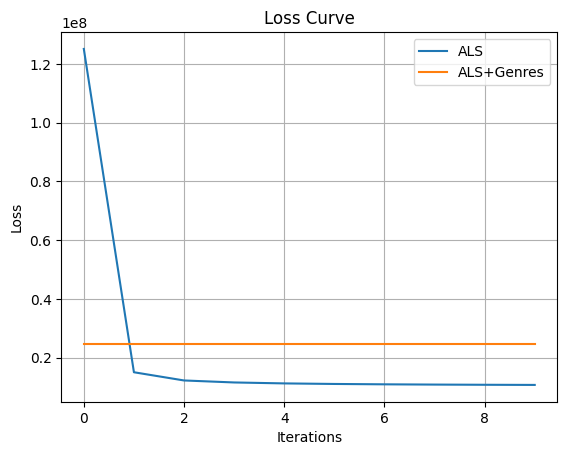

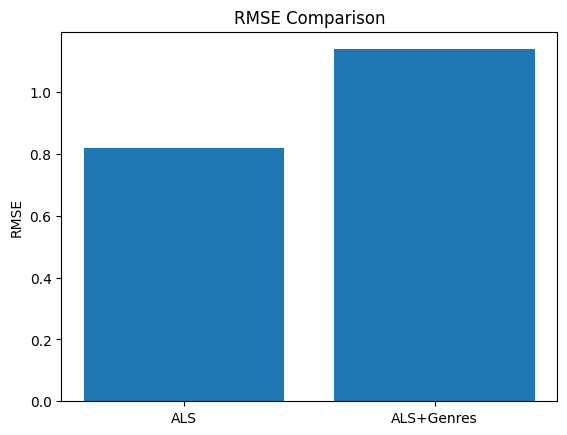

In [16]:
# Loss curve
plt.figure()
plt.plot(loss_base, label="ALS")
plt.plot(loss_gen, label="ALS+Genres")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid()
plt.savefig("loss.png")
plt.show()

# RMSE comparison
models = ["ALS", "ALS+Genres"]

plt.figure()
plt.bar(models, [rmse_base, rmse_gen])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.savefig("rmse.png")
plt.show()

## 12. Precision and Recall Comparison

Bar charts are used to compare:

- Precision@10
- Recall@10

Between:
- ALS
- ALS + Genres

This highlights improvements in recommendation quality.

<Figure size 640x480 with 0 Axes>

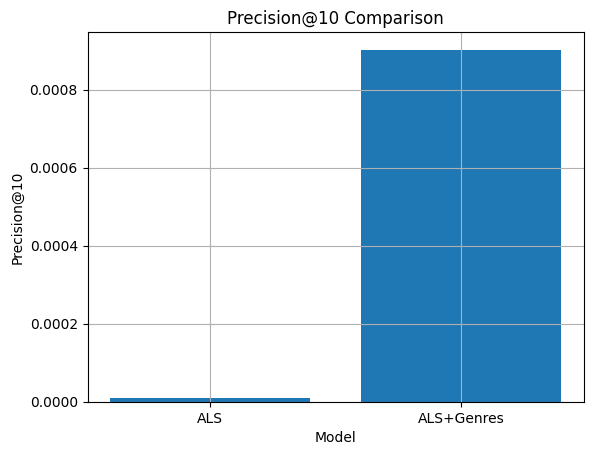

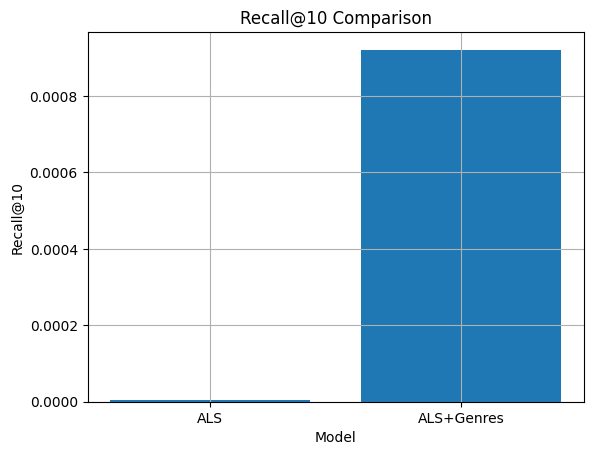

In [17]:
plt.figure()
x = ["ALS", "ALS+Genres"]

precision_vals = [prec_base, prec_gen]
recall_vals = [rec_base, rec_gen]

# Precision
plt.figure()
plt.bar(x, precision_vals)
plt.title("Precision@10 Comparison")
plt.xlabel("Model")
plt.ylabel("Precision@10")
plt.grid()
plt.savefig("precision.png")
plt.show()

# Recall
plt.figure()
plt.bar(x, recall_vals)
plt.title("Recall@10 Comparison")
plt.xlabel("Model")
plt.ylabel("Recall@10")
plt.grid()
plt.savefig("recall.png")
plt.show()

## 13. Generating Predictions

This section computes predicted ratings for the test dataset using:

- Baseline ALS
- Genre-enhanced ALS

Predictions are used for evaluation and error analysis.

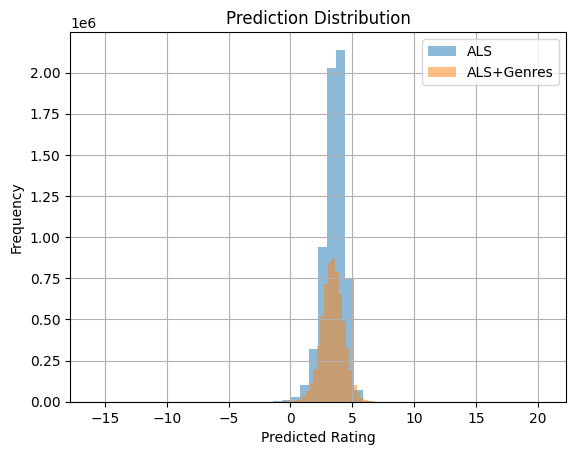

In [18]:
def get_predictions(df, P, Q):
    preds = []
    for r in df.itertuples():
        preds.append(P[r.user] @ Q[r.movie])
    return np.array(preds)

pred_base = get_predictions(test_df, P_base, Q_base)
pred_gen = get_predictions(test_df, P_gen, Q_gen)

plt.figure()
plt.hist(pred_base, bins=50, alpha=0.5, label="ALS")
plt.hist(pred_gen, bins=50, alpha=0.5, label="ALS+Genres")

plt.title("Prediction Distribution")
plt.xlabel("Predicted Rating")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.savefig("prediction_dist.png")
plt.show()

## 14. Error Analysis

Prediction errors are calculated for both models.

Purpose:
- Compare prediction deviations
- Identify which model performs better

Lower errors indicate better accuracy.

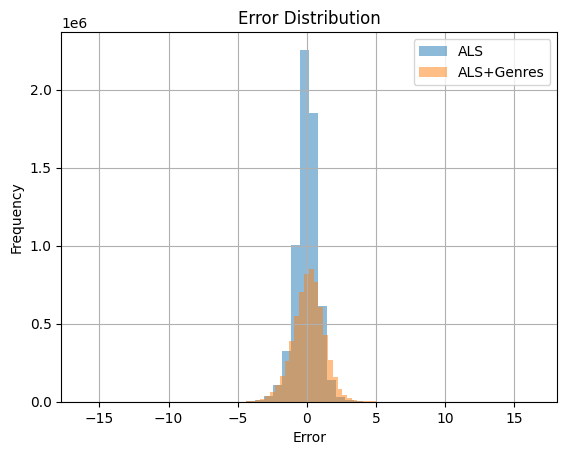

In [19]:
errors_base = []
errors_gen = []

for r in test_df.itertuples():
    pred_b = P_base[r.user] @ Q_base[r.movie]
    pred_g = P_gen[r.user] @ Q_gen[r.movie]

    errors_base.append(r.rating - pred_b)
    errors_gen.append(r.rating - pred_g)

plt.figure()
plt.hist(errors_base, bins=50, alpha=0.5, label="ALS")
plt.hist(errors_gen, bins=50, alpha=0.5, label="ALS+Genres")

plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.savefig("error_dist.png")
plt.show()

## 15. Generating Recommendations

Top-K movie recommendations are generated for a sample user.

Steps:
- Compute scores for all movies
- Rank movies by predicted preference
- Select top-K items

This demonstrates real-world recommendation output.

In [20]:
def recommend_movies(user_id, P, Q, k=5):
    scores = P[user_id] @ Q.T
    ranked = np.argsort(scores)[::-1]
    return ranked[:k]

user_example = 0

rec_base = recommend_movies(user_example, P_base, Q_base)
rec_gen = recommend_movies(user_example, P_gen, Q_gen)

print("Top recommendations (ALS):", rec_base)
print("Top recommendations (ALS+Genres):", rec_gen)

Top recommendations (ALS): [33816 28979  8061 32851 44487]
Top recommendations (ALS+Genres): [ 7030 12113 81286 41357  2918]


## 16. Genre Distribution Analysis

A histogram shows the number of genres per movie.

Purpose:
- Understand dataset characteristics
- Analyze genre diversity

This helps interpret model behavior.

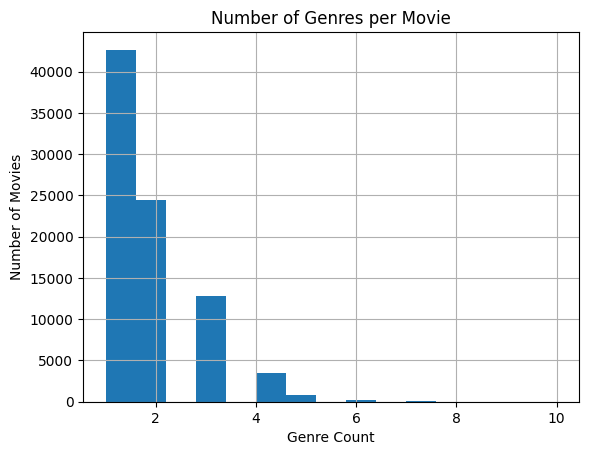

In [23]:
genre_counts = np.sum(genre_matrix > 0, axis=1)

plt.figure()
plt.hist(genre_counts, bins=15)

plt.title("Number of Genres per Movie")
plt.xlabel("Genre Count")
plt.ylabel("Number of Movies")
plt.grid()
plt.savefig("genre_count.png")
plt.show()

## 17. Convergence Comparison

A detailed comparison of convergence between:

- ALS
- ALS + Genres

Helps evaluate:
- Stability
- Speed of convergence
- Effect of genre features

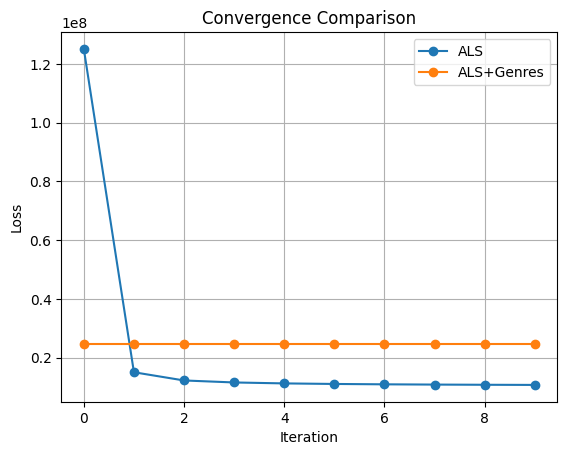

In [24]:
plt.figure()

plt.plot(loss_base, marker='o', label="ALS")
plt.plot(loss_gen, marker='o', label="ALS+Genres")

plt.title("Convergence Comparison")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("convergence.png")
plt.show()